# Task 4: Double Down Analysis

This analysis explores the "Double Down" ability. We evaluate:
1. Which categories are chosen most frequently for a double down?
2. Which levels are chosen most frequently for a double down?
3. How does the number of active skills affect the decision to double down?
4. How do these factors differ between `Control` runs and `Tool` runs?
5. How does the `Tool` mode's double down selection compare against its overall baseline distribution?

Loaded 299 Double Down events.

--- Fisher's Exact Test: Double Down Category (Control vs Tool) ---


,Value,Control,Tool,p-value,Significant
5,"Language, Linguistics & Cryptography",8/131 (6.1%),2/168 (1.2%),0.023882,Yes
1,Pop Culture & Entertainment,7/131 (5.3%),19/168 (11.3%),0.096728,No
4,Geography & Travel,6/131 (4.6%),3/168 (1.8%),0.186821,No
3,Science & Mathematics,78/131 (59.5%),112/168 (66.7%),0.226696,No
0,Technology & Computer Science,21/131 (16.0%),20/168 (11.9%),0.314501,No
6,History & Politics,5/131 (3.8%),4/168 (2.4%),0.511882,No
2,"Arts, Literature & Museums",6/131 (4.6%),8/168 (4.8%),1.000000,No


------------------------------------------------------------

--- Fisher's Exact Test: Double Down Level (Control vs Tool) ---


,Value,Control,Tool,p-value,Significant
2,3,27/131 (20.6%),46/168 (27.4%),0.221944,No
0,1,31/131 (23.7%),31/168 (18.5%),0.314662,No
1,2,73/131 (55.7%),91/168 (54.2%),0.815506,No


------------------------------------------------------------


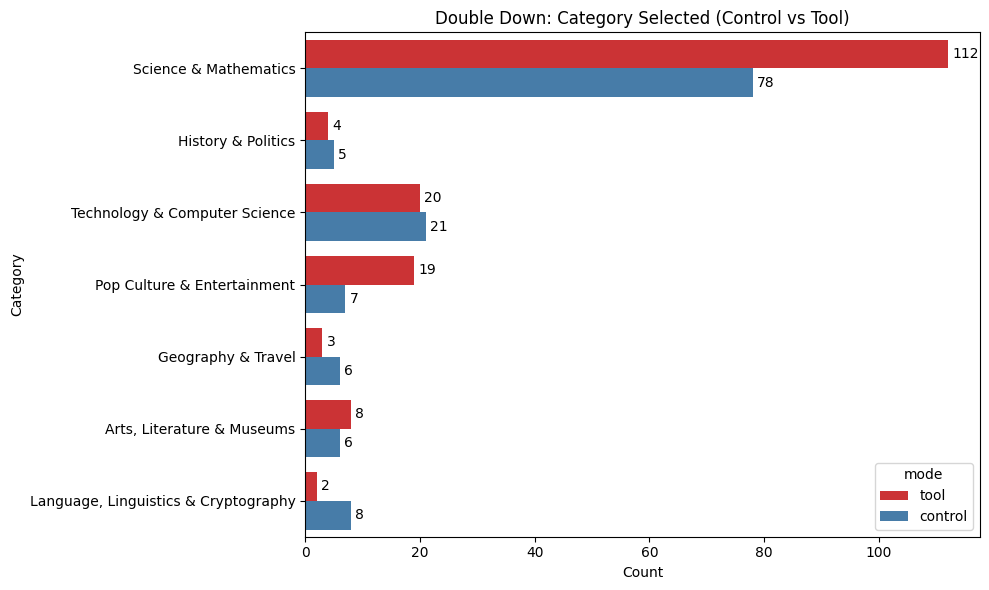

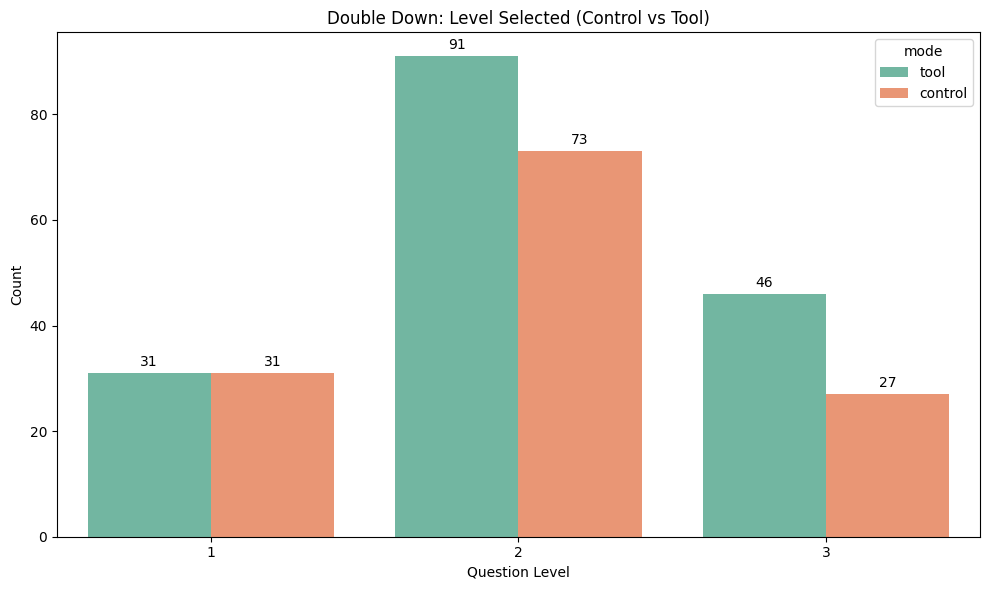

/tmp/ipykernel_69968/2765991054.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax3 = sns.countplot(data=df_dd_tool, x='active_skills_count', palette='Set3')


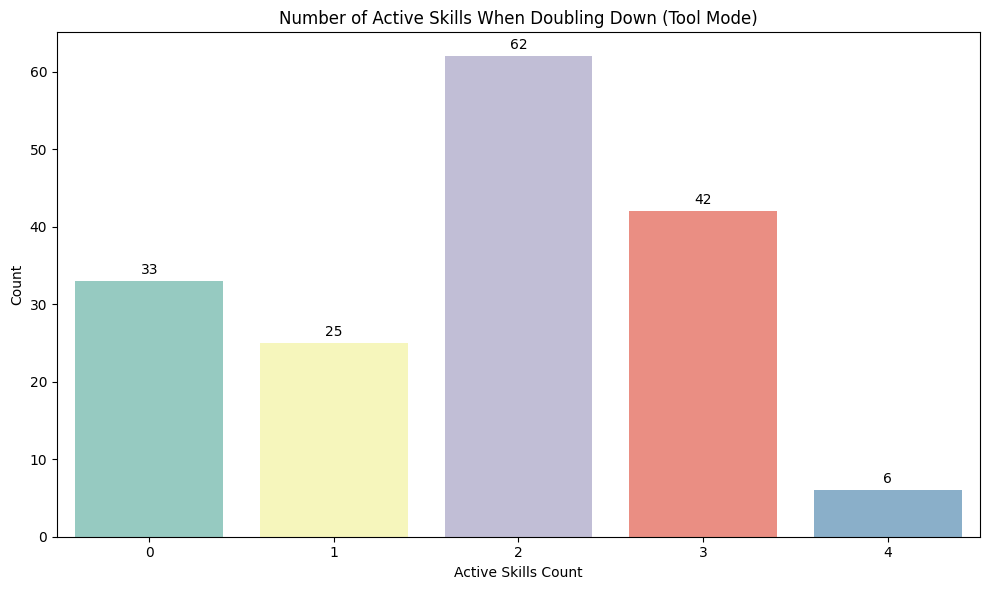


--- Fisher's Exact Test: Tool Mode Categories (Baseline vs Double Down) ---


,Value,Baseline,Double Down,p-value,Significant
6,"Language, Linguistics & Cryptography",31/542 (5.7%),2/168 (1.2%),0.011313,Yes
4,Science & Mathematics,324/542 (59.8%),112/168 (66.7%),0.123128,No
5,Geography & Travel,17/542 (3.1%),3/168 (1.8%),0.435653,No
2,"Arts, Literature & Museums",20/542 (3.7%),8/168 (4.8%),0.502570,No
0,Technology & Computer Science,70/542 (12.9%),20/168 (11.9%),0.791809,No
1,Pop Culture & Entertainment,62/542 (11.4%),19/168 (11.3%),1.000000,No
3,Other,3/542 (0.6%),0/168 (0.0%),1.000000,No
7,History & Politics,15/542 (2.8%),4/168 (2.4%),1.000000,No


------------------------------------------------------------


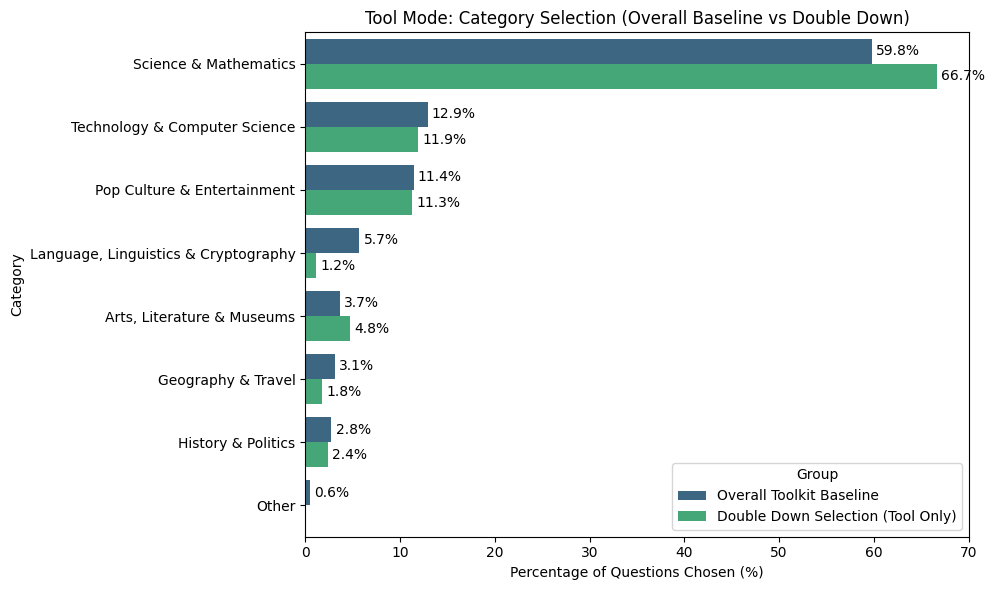


--- Fisher's Exact Test: Tool Mode Levels (Baseline vs Double Down) ---


,Value,Baseline,Double Down,p-value,Significant
0,1,150/542 (27.7%),31/168 (18.5%),0.019515,Yes
1,2,242/542 (44.6%),91/168 (54.2%),0.033792,Yes
2,3,150/542 (27.7%),46/168 (27.4%),1.000000,No


------------------------------------------------------------


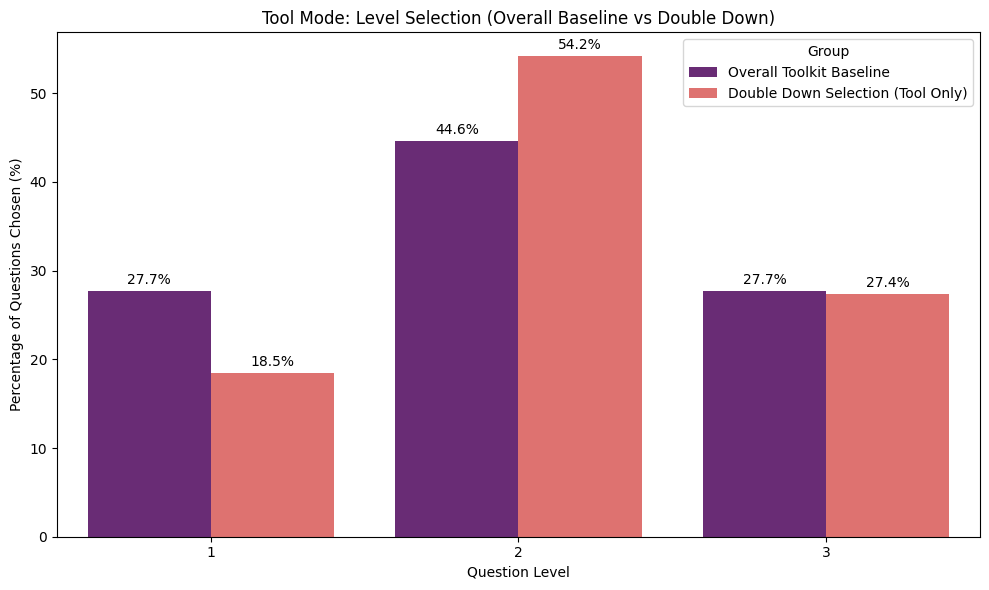

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import fisher_exact

# Helper to run 2x2 Fisher's Exact Test for each unique value (One vs Rest)
def print_fisher_results(series1, series2, group1_name, group2_name, label):
    print(f"\n--- Fisher's Exact Test: {label} ({group1_name} vs {group2_name}) ---")
    unique_vals = set(series1.dropna().unique()).union(set(series2.dropna().unique()))
    n1, n2 = len(series1), len(series2)
    
    if n1 == 0 or n2 == 0:
        print("Not enough data to run Fisher's Exact Test.")
        return

    results = []
    for val in unique_vals:
        k1 = (series1 == val).sum()
        k2 = (series2 == val).sum()
        
        # 2x2 Contingency Table
        #             Group 1    Group 2
        # Is Val        k1         k2
        # Not Val     n1-k1      n2-k2
        table = [[k1, k2], [n1 - k1, n2 - k2]]
        _, p_val = fisher_exact(table)
        
        results.append({
            'Value': val,
            f'{group1_name}': f"{k1}/{n1} ({k1/n1*100:.1f}%)",
            f'{group2_name}': f"{k2}/{n2} ({k2/n2*100:.1f}%)",
            'p-value': p_val,
            'Significant': 'Yes' if p_val < 0.05 else 'No'
        })
    
    df_res = pd.DataFrame(results).sort_values('p-value')
    display(df_res)
    print("-" * 60)

# Load Double Down data
with open('../scripts/parsed_task4.json', 'r') as f:
    dd_data = json.load(f)
df_dd = pd.DataFrame(dd_data)

if df_dd.empty:
    print("No double down actions found.")
else:
    print(f"Loaded {len(df_dd)} Double Down events.")
    
    # Load Overall Baseline data
    with open('../scripts/parsed_data.json', 'r') as f:
        all_data = json.load(f)
        
    all_tool_categories = []
    all_tool_levels = []
    for r in all_data:
        if r['mode'] == 'tool':
            for q in r['questions_attempted']:
                all_tool_categories.append(q['category'])
                all_tool_levels.append(int(q['level']))
                
    # Split Control and Tool for Double Down comparisons
    df_dd_control = df_dd[df_dd['mode'] == 'control']
    df_dd_tool = df_dd[df_dd['mode'] == 'tool']

    # Fisher Tests: Control vs Tool (Double Down)
    print_fisher_results(df_dd_control['category'], df_dd_tool['category'], 'Control', 'Tool', 'Double Down Category')
    print_fisher_results(df_dd_control['level'], df_dd_tool['level'], 'Control', 'Tool', 'Double Down Level')
    # Removed active_skills_count comparison as requested

    # ==========================================================
    # 1. Compare Control vs Tool: Double Down CATEGORY
    # ==========================================================
    plt.figure(figsize=(10, 6))
    ax1 = sns.countplot(data=df_dd, y='category', hue='mode', palette='Set1')
    plt.title('Double Down: Category Selected (Control vs Tool)')
    plt.xlabel('Count')
    plt.ylabel('Category')
    for container in ax1.containers:
        ax1.bar_label(container, padding=3)
    plt.tight_layout()
    plt.show()

    # ==========================================================
    # 2. Compare Control vs Tool: Double Down LEVEL
    # ==========================================================
    plt.figure(figsize=(10, 6))
    ax2 = sns.countplot(data=df_dd, x='level', hue='mode', palette='Set2')
    plt.title('Double Down: Level Selected (Control vs Tool)')
    plt.xlabel('Question Level')
    plt.ylabel('Count')
    for container in ax2.containers:
        ax2.bar_label(container, padding=3)
    plt.tight_layout()
    plt.show()

    # ==========================================================
    # 3. Active Skills Count During Double Down (Tool Only)
    # ==========================================================
    plt.figure(figsize=(10, 6))
    # Use only df_dd_tool and remove the 'hue' parameter
    ax3 = sns.countplot(data=df_dd_tool, x='active_skills_count', palette='Set3')
    plt.title('Number of Active Skills When Doubling Down (Tool Mode)')
    plt.xlabel('Active Skills Count')
    plt.ylabel('Count')
    for container in ax3.containers:
        ax3.bar_label(container, padding=3)
    plt.tight_layout()
    plt.show()

    # ==========================================================
    # 4. Tool Mode: Double Down vs Overall Baseline - CATEGORY
    # ==========================================================
    # Baseline Category
    df_overall_cat = pd.DataFrame(all_tool_categories, columns=['category'])
    overall_cat_counts = df_overall_cat['category'].value_counts(normalize=True).reset_index()
    overall_cat_counts.columns = ['Category', 'Percentage']
    overall_cat_counts['Group'] = 'Overall Toolkit Baseline'

    # Tool Double Down Category
    dd_cat_counts = df_dd_tool['category'].value_counts(normalize=True).reset_index()
    dd_cat_counts.columns = ['Category', 'Percentage']
    dd_cat_counts['Group'] = 'Double Down Selection (Tool Only)'

    # Fisher Test: Baseline vs Double Down (Tool Only) - Category
    print_fisher_results(df_overall_cat['category'], df_dd_tool['category'], 'Baseline', 'Double Down', 'Tool Mode Categories')

    combined_cat = pd.concat([overall_cat_counts, dd_cat_counts])
    combined_cat['Percentage'] *= 100

    plt.figure(figsize=(10, 6))
    ax4 = sns.barplot(data=combined_cat, y='Category', x='Percentage', hue='Group', palette='viridis')
    plt.title('Tool Mode: Category Selection (Overall Baseline vs Double Down)')
    plt.xlabel('Percentage of Questions Chosen (%)')
    plt.ylabel('Category')
    for container in ax4.containers:
        ax4.bar_label(container, fmt='%.1f%%', padding=3)
    plt.tight_layout()
    plt.show()

    # ==========================================================
    # 5. Tool Mode: Double Down vs Overall Baseline - LEVEL
    # ==========================================================
    # Baseline Level
    df_overall_lvl = pd.DataFrame(all_tool_levels, columns=['level'])
    overall_lvl_counts = df_overall_lvl['level'].value_counts(normalize=True).reset_index()
    overall_lvl_counts.columns = ['Level', 'Percentage']
    overall_lvl_counts['Group'] = 'Overall Toolkit Baseline'

    # Tool Double Down Level
    dd_lvl_counts = df_dd_tool['level'].value_counts(normalize=True).reset_index()
    dd_lvl_counts.columns = ['Level', 'Percentage']
    dd_lvl_counts['Group'] = 'Double Down Selection (Tool Only)'

    # Fisher Test: Baseline vs Double Down (Tool Only) - Level
    print_fisher_results(df_overall_lvl['level'], df_dd_tool['level'], 'Baseline', 'Double Down', 'Tool Mode Levels')

    combined_lvl = pd.concat([overall_lvl_counts, dd_lvl_counts])
    combined_lvl['Percentage'] *= 100

    plt.figure(figsize=(10, 6))
    ax5 = sns.barplot(data=combined_lvl, x='Level', y='Percentage', hue='Group', palette='magma')
    plt.title('Tool Mode: Level Selection (Overall Baseline vs Double Down)')
    plt.ylabel('Percentage of Questions Chosen (%)')
    plt.xlabel('Question Level')
    for container in ax5.containers:
        ax5.bar_label(container, fmt='%.1f%%', padding=3)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_69968/4205868332.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax6 = sns.barplot(data=df_skill_dd_rate, x='Active Skills Count', y='Double Down Rate (%)', palette='coolwarm')


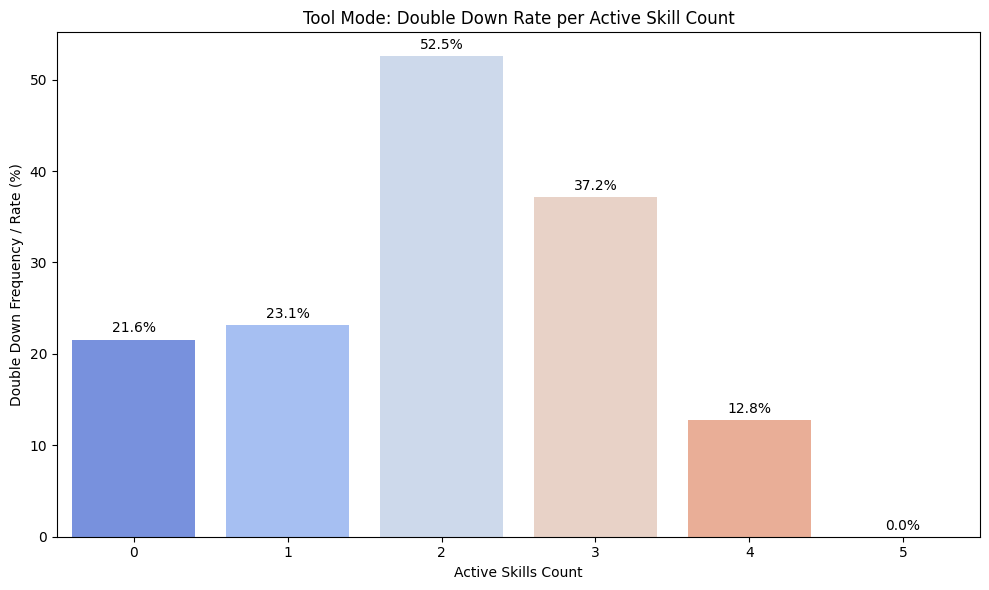

Raw Counts Table:


,Active Skills Count,Total Opportunities,Double Downs,Double Down Rate (%)
0,0,153,33.0,21.568627
3,1,108,25.0,23.148148
1,2,118,62.0,52.542373
2,3,113,42.0,37.168142
4,4,47,6.0,12.765957
5,5,3,0.0,0.000000


In [2]:
# ==========================================================
# 6. Double Down Rate per Active Skill Count (Tool Only)
# This chart compares the number of double downs against the 
# total opportunities (questions faced) at each skill count.
# ==========================================================

# Calculate the total number of questions answered in tool mode for each active skill count
tool_skill_counts = []
for r in all_data:
    if r['mode'] == 'tool':
        for q in r['questions_attempted']:
            # 'active_skills' usually has a length, check if we stored it directly
            # If not, count the length of the list, fallback to what was stored
            if 'active_skills' in q:
                tool_skill_counts.append(len(q['active_skills']))
            elif 'active_skills_count' in q:
                tool_skill_counts.append(q['active_skills_count'])
            else:
                tool_skill_counts.append(0)
            
df_tool_skills = pd.DataFrame(tool_skill_counts, columns=['active_skills_count'])

# Count total opportunities for each skill count
skill_opportunities = df_tool_skills['active_skills_count'].value_counts().rename('Total Opportunities')

# Count actual double downs for each skill count
dd_by_skill = df_dd_tool['active_skills_count'].value_counts().rename('Double Downs')

# Combine and calculate the percentage rate
df_skill_dd_rate = pd.concat([skill_opportunities, dd_by_skill], axis=1).fillna(0)
df_skill_dd_rate['Double Down Rate (%)'] = (df_skill_dd_rate['Double Downs'] / df_skill_dd_rate['Total Opportunities']) * 100
df_skill_dd_rate = df_skill_dd_rate.reset_index().rename(columns={'active_skills_count': 'Active Skills Count'}).sort_values('Active Skills Count')

# Plot the Rate
plt.figure(figsize=(10, 6))
ax6 = sns.barplot(data=df_skill_dd_rate, x='Active Skills Count', y='Double Down Rate (%)', palette='coolwarm')
plt.title('Tool Mode: Double Down Rate per Active Skill Count')
plt.xlabel('Active Skills Count')
plt.ylabel('Double Down Frequency / Rate (%)')
for container in ax6.containers:
    ax6.bar_label(container, fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.show()

# Display the raw numbers as well
print("Raw Counts Table:")
display(df_skill_dd_rate)